In [1]:
import pandas as pd

import mysql.connector
from config import DB_CONFIG

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
conn = mysql.connector.connect(**DB_CONFIG)

if conn.is_connected():
    print("Database Connected Successfully!")

Database Connected Successfully!


In [3]:
df = pd.read_sql('select * from ecommerce_cleaned', con = conn)
conn.close()

C:\Users\Ekamjot Singh\AppData\Local\Temp\ipykernel_21616\3627570471.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql('select * from ecommerce_cleaned', con = conn)


In [4]:
print("rows :", df.shape[0],"\ncolumns :",df.shape[1])
print(df.dtypes)

rows : 5628 
columns : 20
CustomerID                       int64
Churn                            int64
Tenure                           int64
PreferredLoginDevice            object
CityTier                         int64
WarehouseToHome                  int64
PreferredPaymentMode            object
Gender                          object
HourSpendOnApp                   int64
NumberOfDeviceRegistered         int64
PreferredOrderCat               object
SatisfactionScore                int64
MaritalStatus                   object
NumberOfAddress                  int64
Complain                         int64
OrderAmountHikeFromlastYear      int64
CouponUsed                       int64
OrderCount                       int64
DaySinceLastOrder                int64
CashbackAmount                 float64
dtype: object


In [5]:
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferredOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4,Mobile Phone,3,6,Debit Card,Female,3,3,Laptop & Accessory,2,Single,9,1,11,1,1,5,159.93
1,50002,1,1,Mobile Phone,1,8,UPI,Male,3,4,Mobile Phone,3,Single,7,1,15,0,1,0,120.90
2,50003,1,1,Mobile Phone,1,30,Debit Card,Male,2,4,Mobile Phone,3,Single,6,1,14,0,1,3,120.28
3,50004,1,0,Mobile Phone,3,15,Debit Card,Male,2,4,Laptop & Accessory,5,Single,8,0,23,0,1,3,134.07
4,50005,1,0,Mobile Phone,1,12,Credit Card,Male,3,3,Mobile Phone,5,Single,3,0,11,1,1,3,129.60


In [6]:
df['Churn'] = df['Churn'].astype(bool)
df['Complain'] = df['Complain'].astype(bool)

In [7]:
categorical_cols = ['PreferredLoginDevice', 'CityTier', 'PreferredPaymentMode', 'Gender',
                     'NumberOfDeviceRegistered', 'PreferredOrderCat', 'SatisfactionScore',
                     'MaritalStatus']

for col in categorical_cols:
    df[col] = df[col].astype('category')

In [8]:
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferredOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,True,4,Mobile Phone,3,6,Debit Card,Female,3,3,Laptop & Accessory,2,Single,9,True,11,1,1,5,159.93
1,50002,True,1,Mobile Phone,1,8,UPI,Male,3,4,Mobile Phone,3,Single,7,True,15,0,1,0,120.90
2,50003,True,1,Mobile Phone,1,30,Debit Card,Male,2,4,Mobile Phone,3,Single,6,True,14,0,1,3,120.28
3,50004,True,0,Mobile Phone,3,15,Debit Card,Male,2,4,Laptop & Accessory,5,Single,8,False,23,0,1,3,134.07
4,50005,True,0,Mobile Phone,1,12,Credit Card,Male,3,3,Mobile Phone,5,Single,3,False,11,1,1,3,129.60


In [9]:
df.dtypes

CustomerID                        int64
Churn                              bool
Tenure                            int64
PreferredLoginDevice           category
CityTier                       category
WarehouseToHome                   int64
PreferredPaymentMode           category
Gender                         category
HourSpendOnApp                    int64
NumberOfDeviceRegistered       category
PreferredOrderCat              category
SatisfactionScore              category
MaritalStatus                  category
NumberOfAddress                   int64
Complain                           bool
OrderAmountHikeFromlastYear       int64
CouponUsed                        int64
OrderCount                        int64
DaySinceLastOrder                 int64
CashbackAmount                  float64
dtype: object

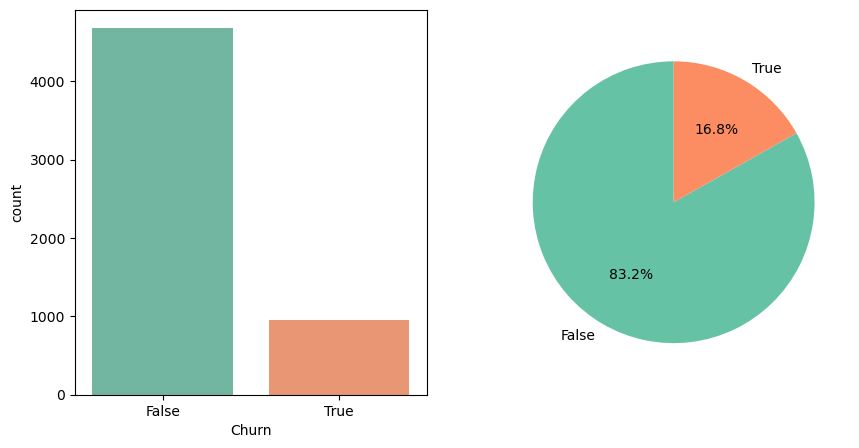

In [10]:
churn_counts = df["Churn"].value_counts()

plt.figure(figsize = (10,5))
plt.subplot(1,2,1)
sns.countplot(data = df, x = "Churn", hue = "Churn", palette = "Set2", legend = False)
plt.subplot(1,2,2)
plt.pie(churn_counts,labels = churn_counts.index, autopct = "%1.1f%%", colors = sns.color_palette("Set2"), startangle = 90)
# plt.savefig('../eda/univariate_target_churn.png', dpi=300, bbox_inches='tight')
plt.show()

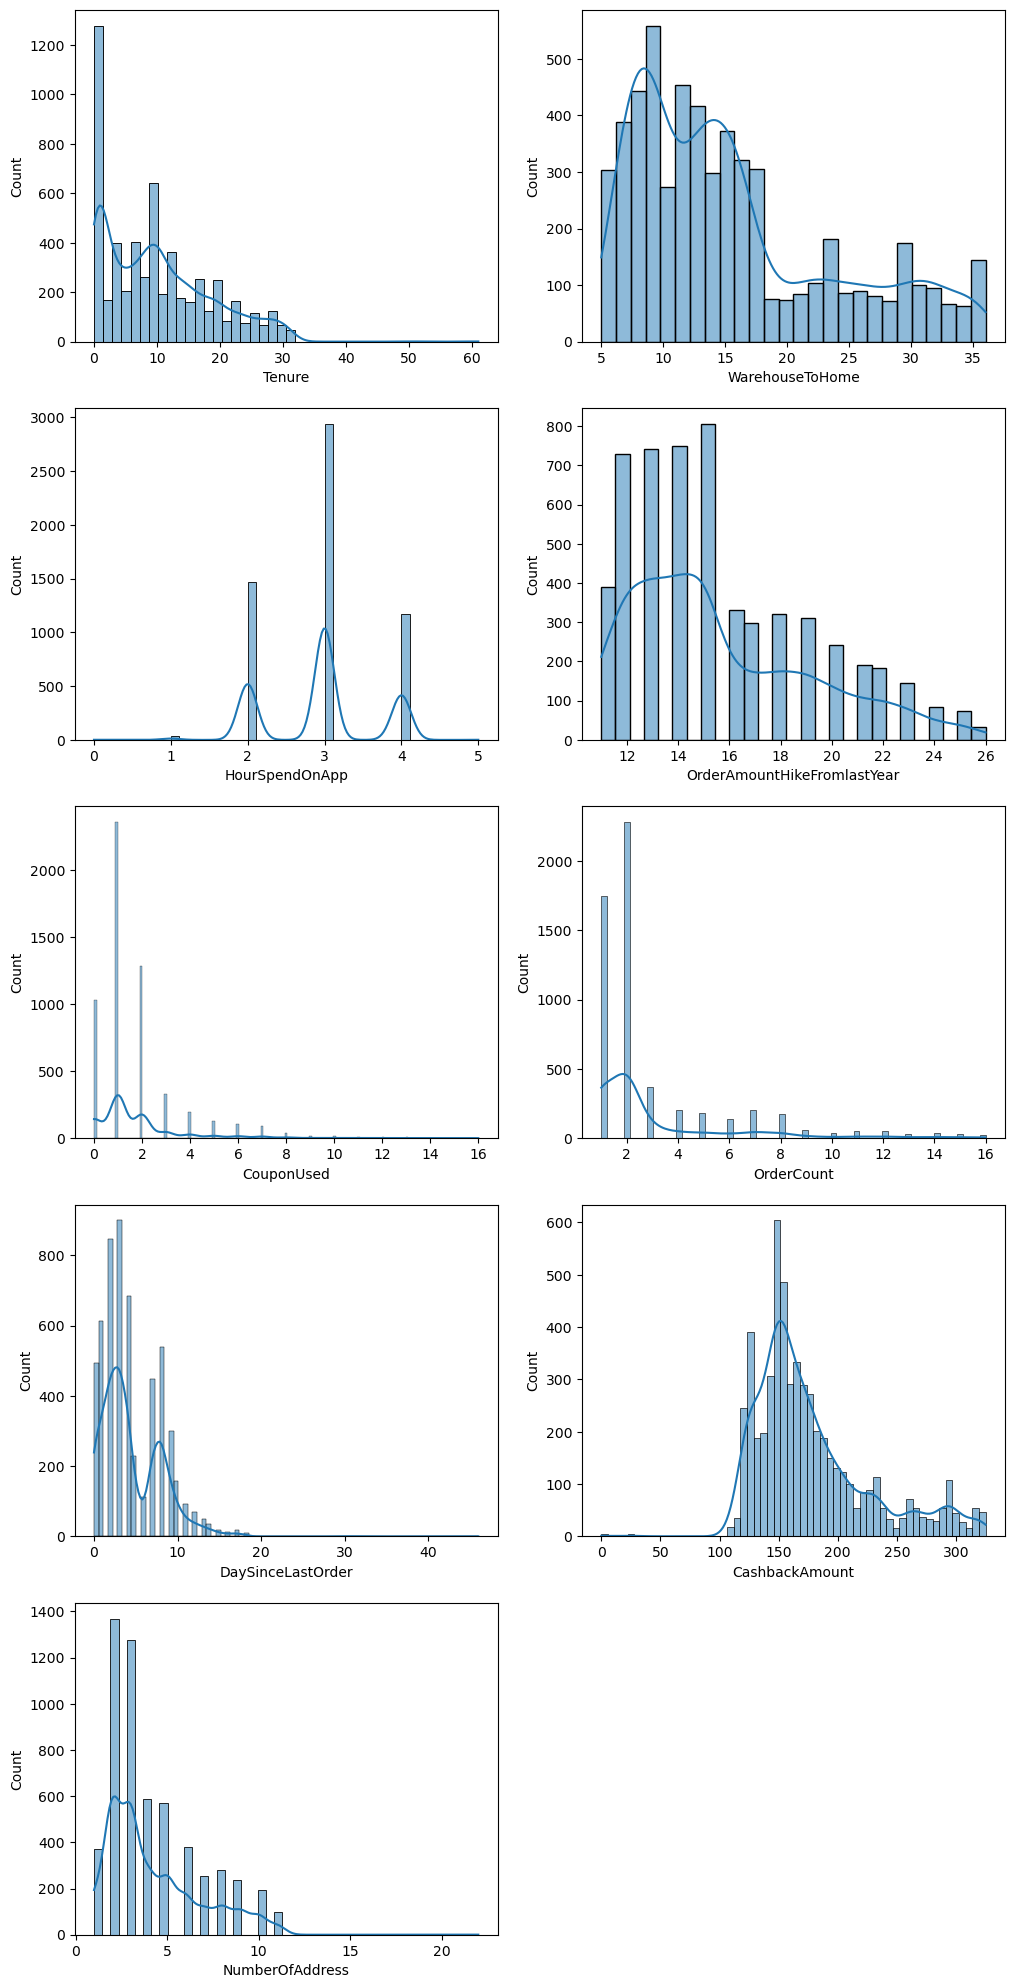

Tenure : 9.0
WarehouseToHome : 13.0
HourSpendOnApp : 3.0
OrderAmountHikeFromlastYear : 15.0
CouponUsed : 1.0
OrderCount : 2.0
DaySinceLastOrder : 3.0
CashbackAmount : 163.33
NumberOfAddress : 3.0


In [11]:
numerical_columns = ["Tenure", "WarehouseToHome", "HourSpendOnApp", "OrderAmountHikeFromlastYear", "CouponUsed", "OrderCount", "DaySinceLastOrder", "CashbackAmount", "NumberOfAddress"]

plt.figure(figsize = (12,25))

for i, numerical_column in enumerate(numerical_columns):
    plt.subplot(5,2,i+1)
    sns.histplot(df[numerical_column], kde = True)
    
# plt.savefig('../eda/univariate_numerical_plots.png', dpi=300, bbox_inches='tight')
plt.show()

for numerical_column in numerical_columns:
    print(f"{numerical_column} : {df[numerical_column].median()}")

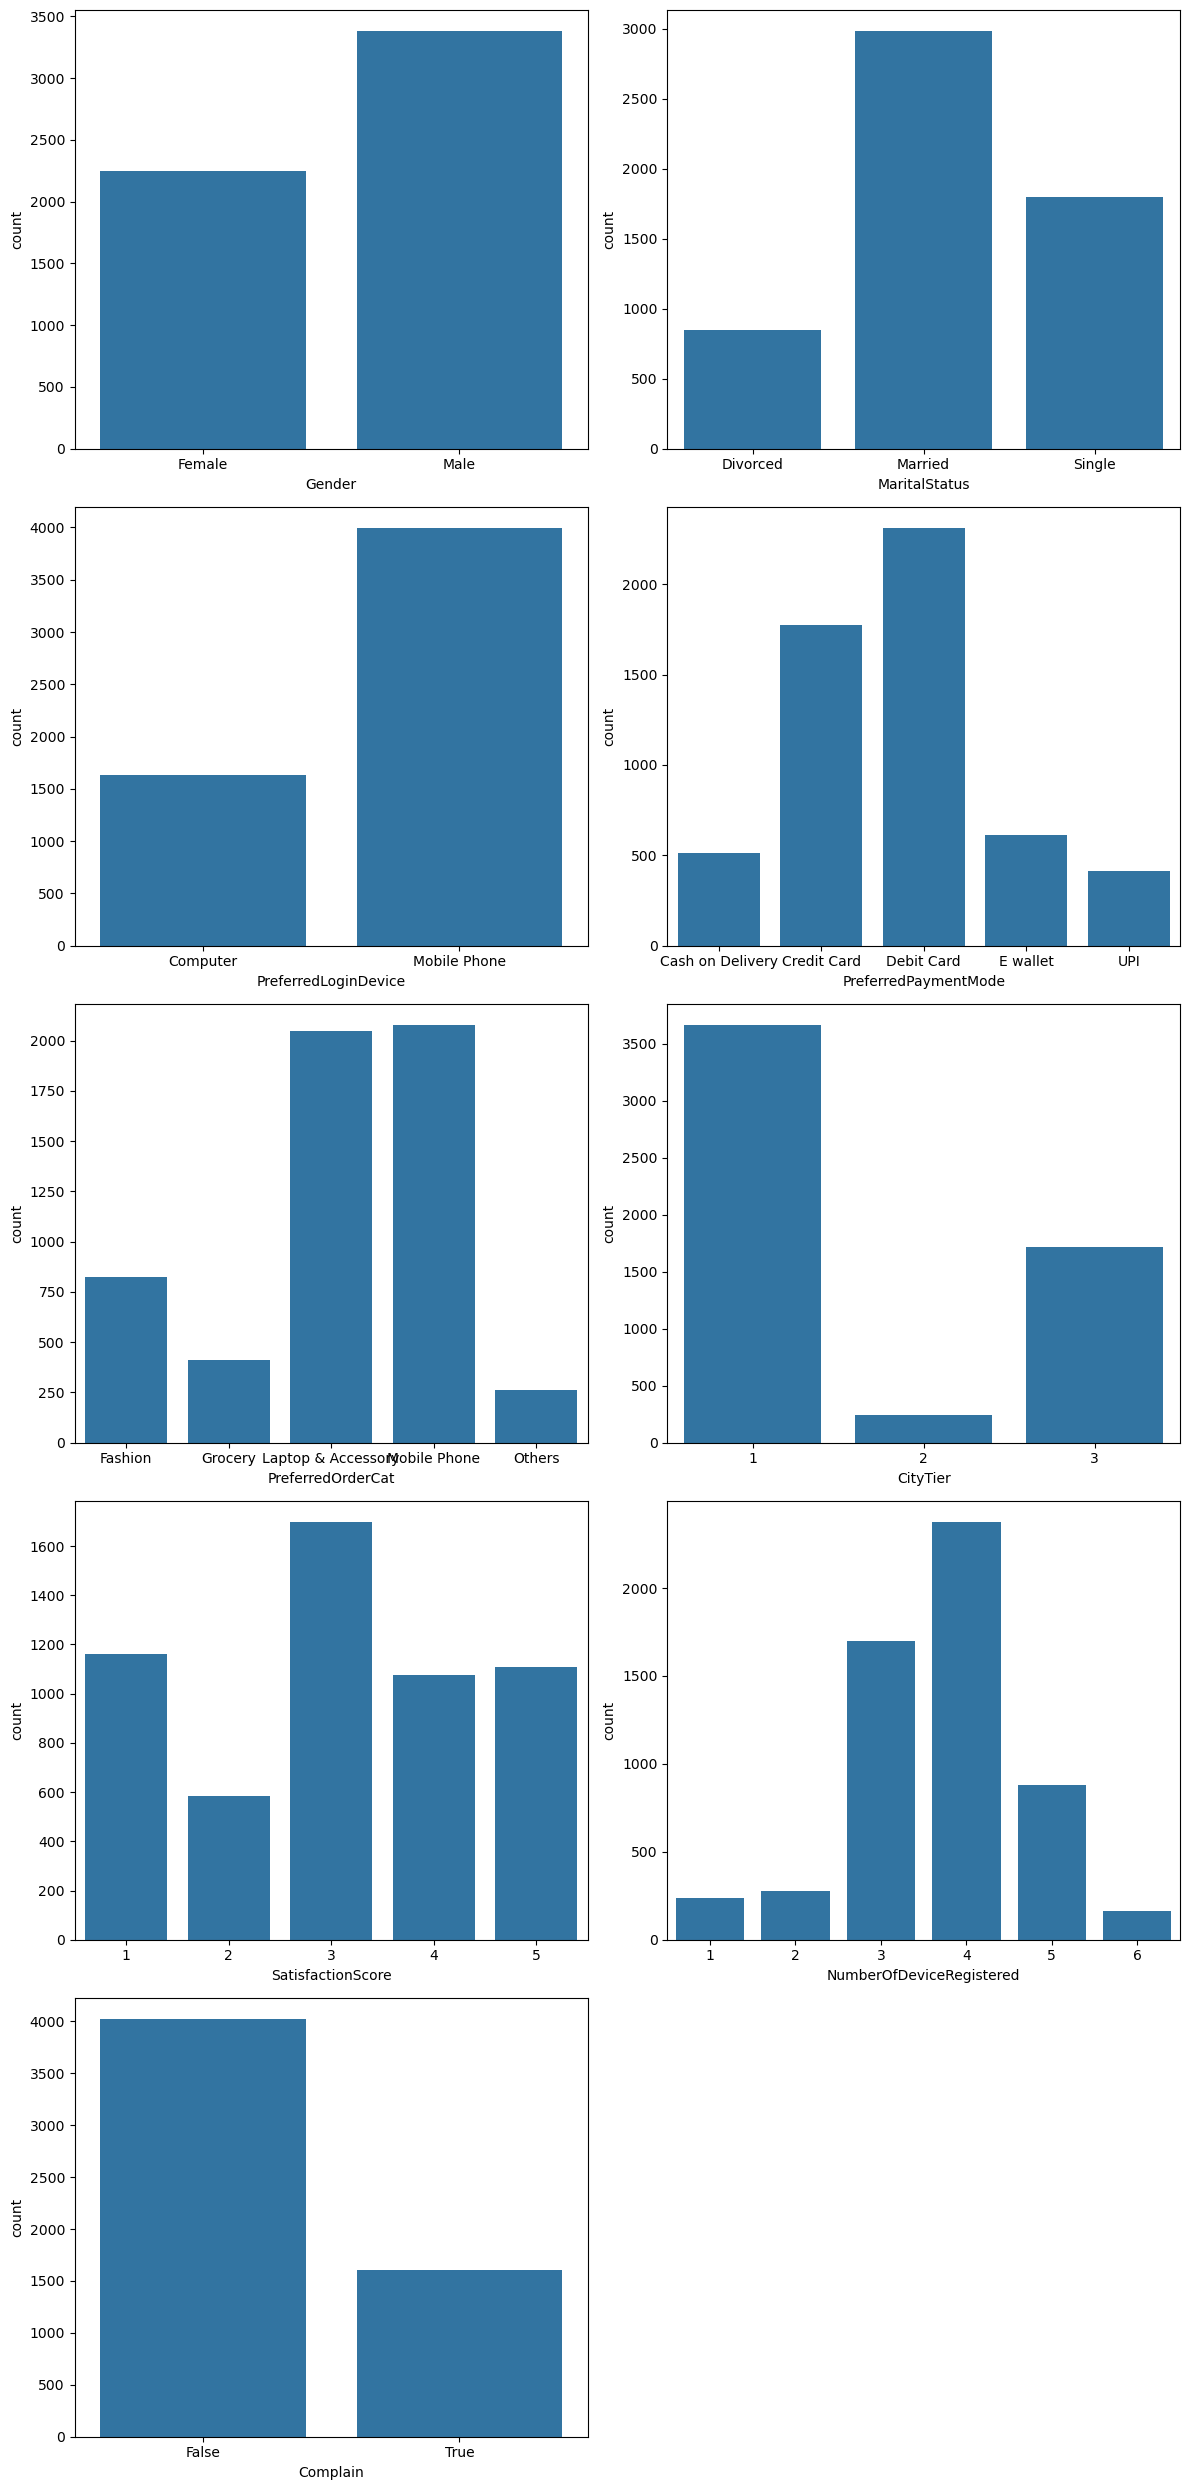

In [12]:
categorical_columns = ["Gender", "MaritalStatus", "PreferredLoginDevice", "PreferredPaymentMode", "PreferredOrderCat", "CityTier", "SatisfactionScore", "NumberOfDeviceRegistered", "Complain"]

plt.figure(figsize = (12,25))

for i, categorical_column in enumerate(categorical_columns):
    plt.subplot(5,2,i+1)
    sns.countplot(data = df, x = categorical_column)
    plt.tight_layout()

# plt.savefig('../eda/univariate_categorical_col_plots.png', dpi=300, bbox_inches='tight')
plt.show()

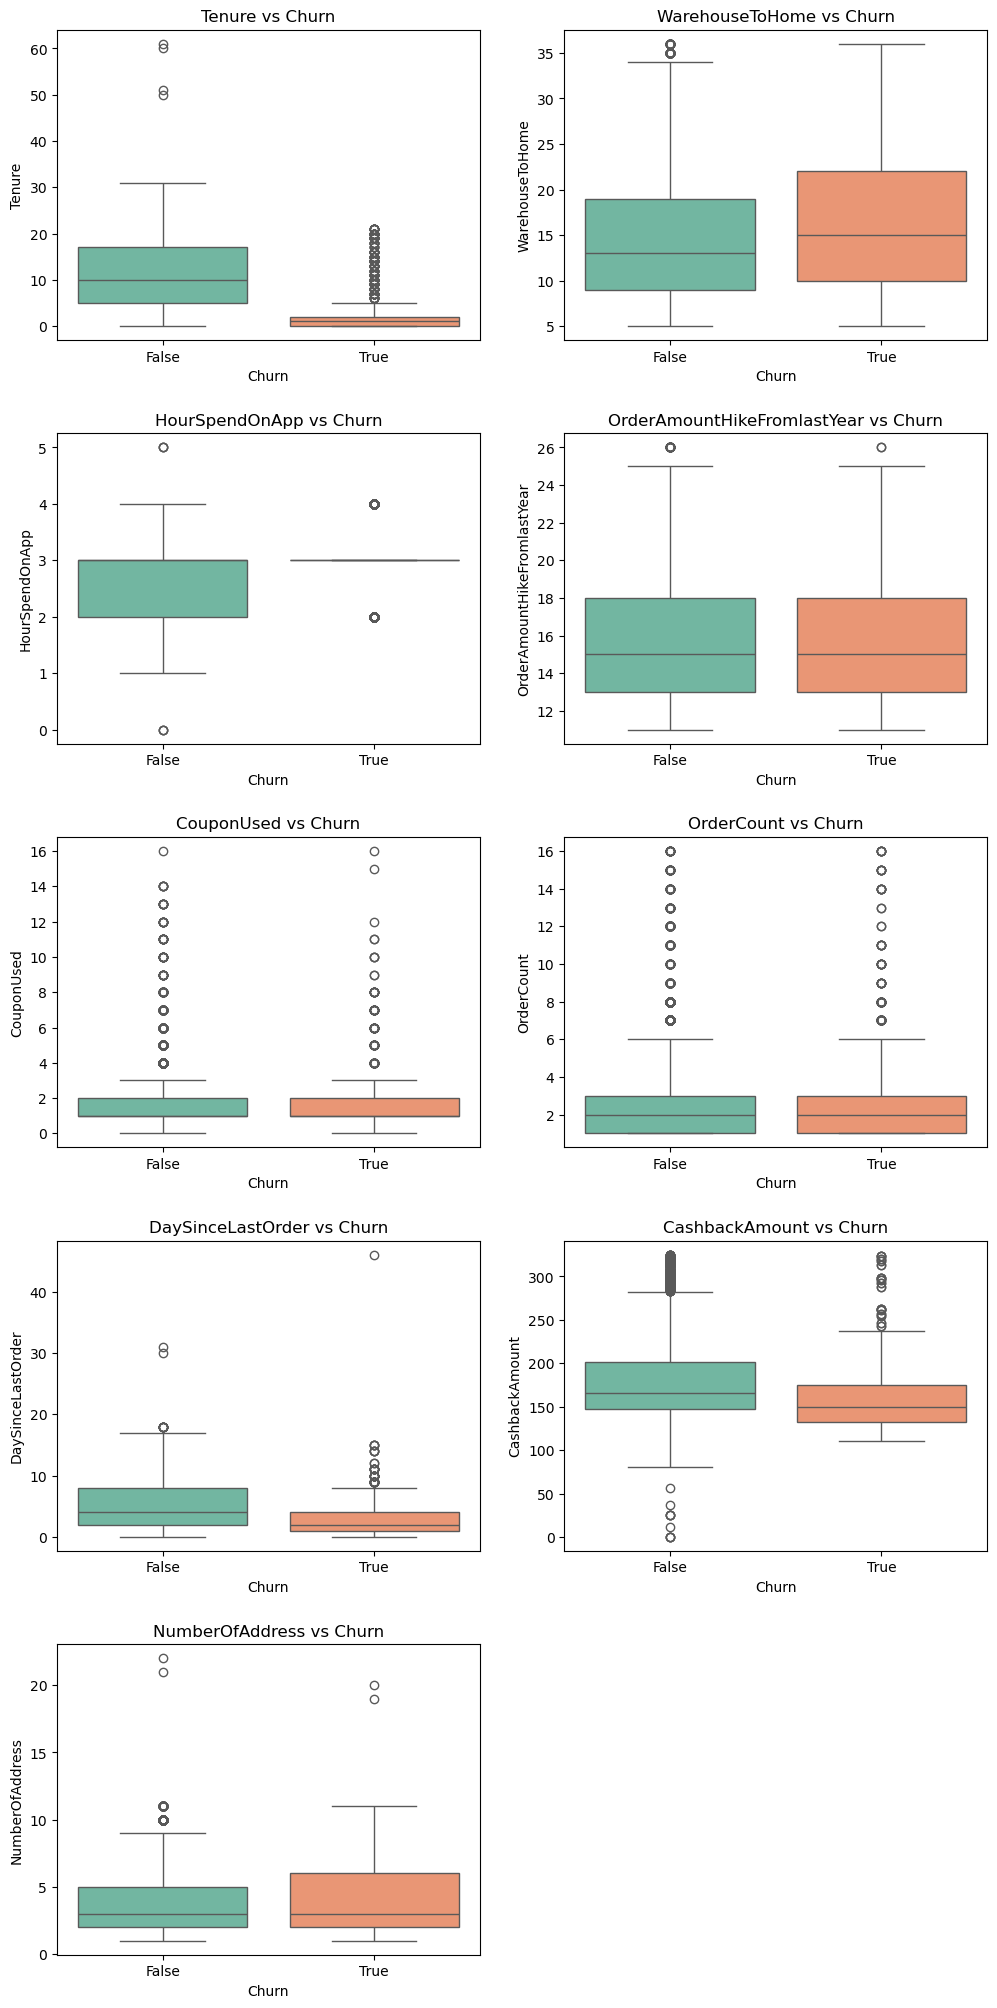

In [13]:
fig, axes = plt.subplots(5,2, figsize = (12,25),gridspec_kw={'hspace': 0.3})
axes = axes.flatten()

for i, numerical_column in enumerate(numerical_columns):
    sns.boxplot(data = df, x = "Churn", y = numerical_column , hue = "Churn", palette = "Set2", legend = False, ax = axes[i])
    axes[i].set_title(f"{numerical_column} vs Churn")

axes[-1].axis('off')
# plt.savefig('../eda/numeric_vs_churn_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

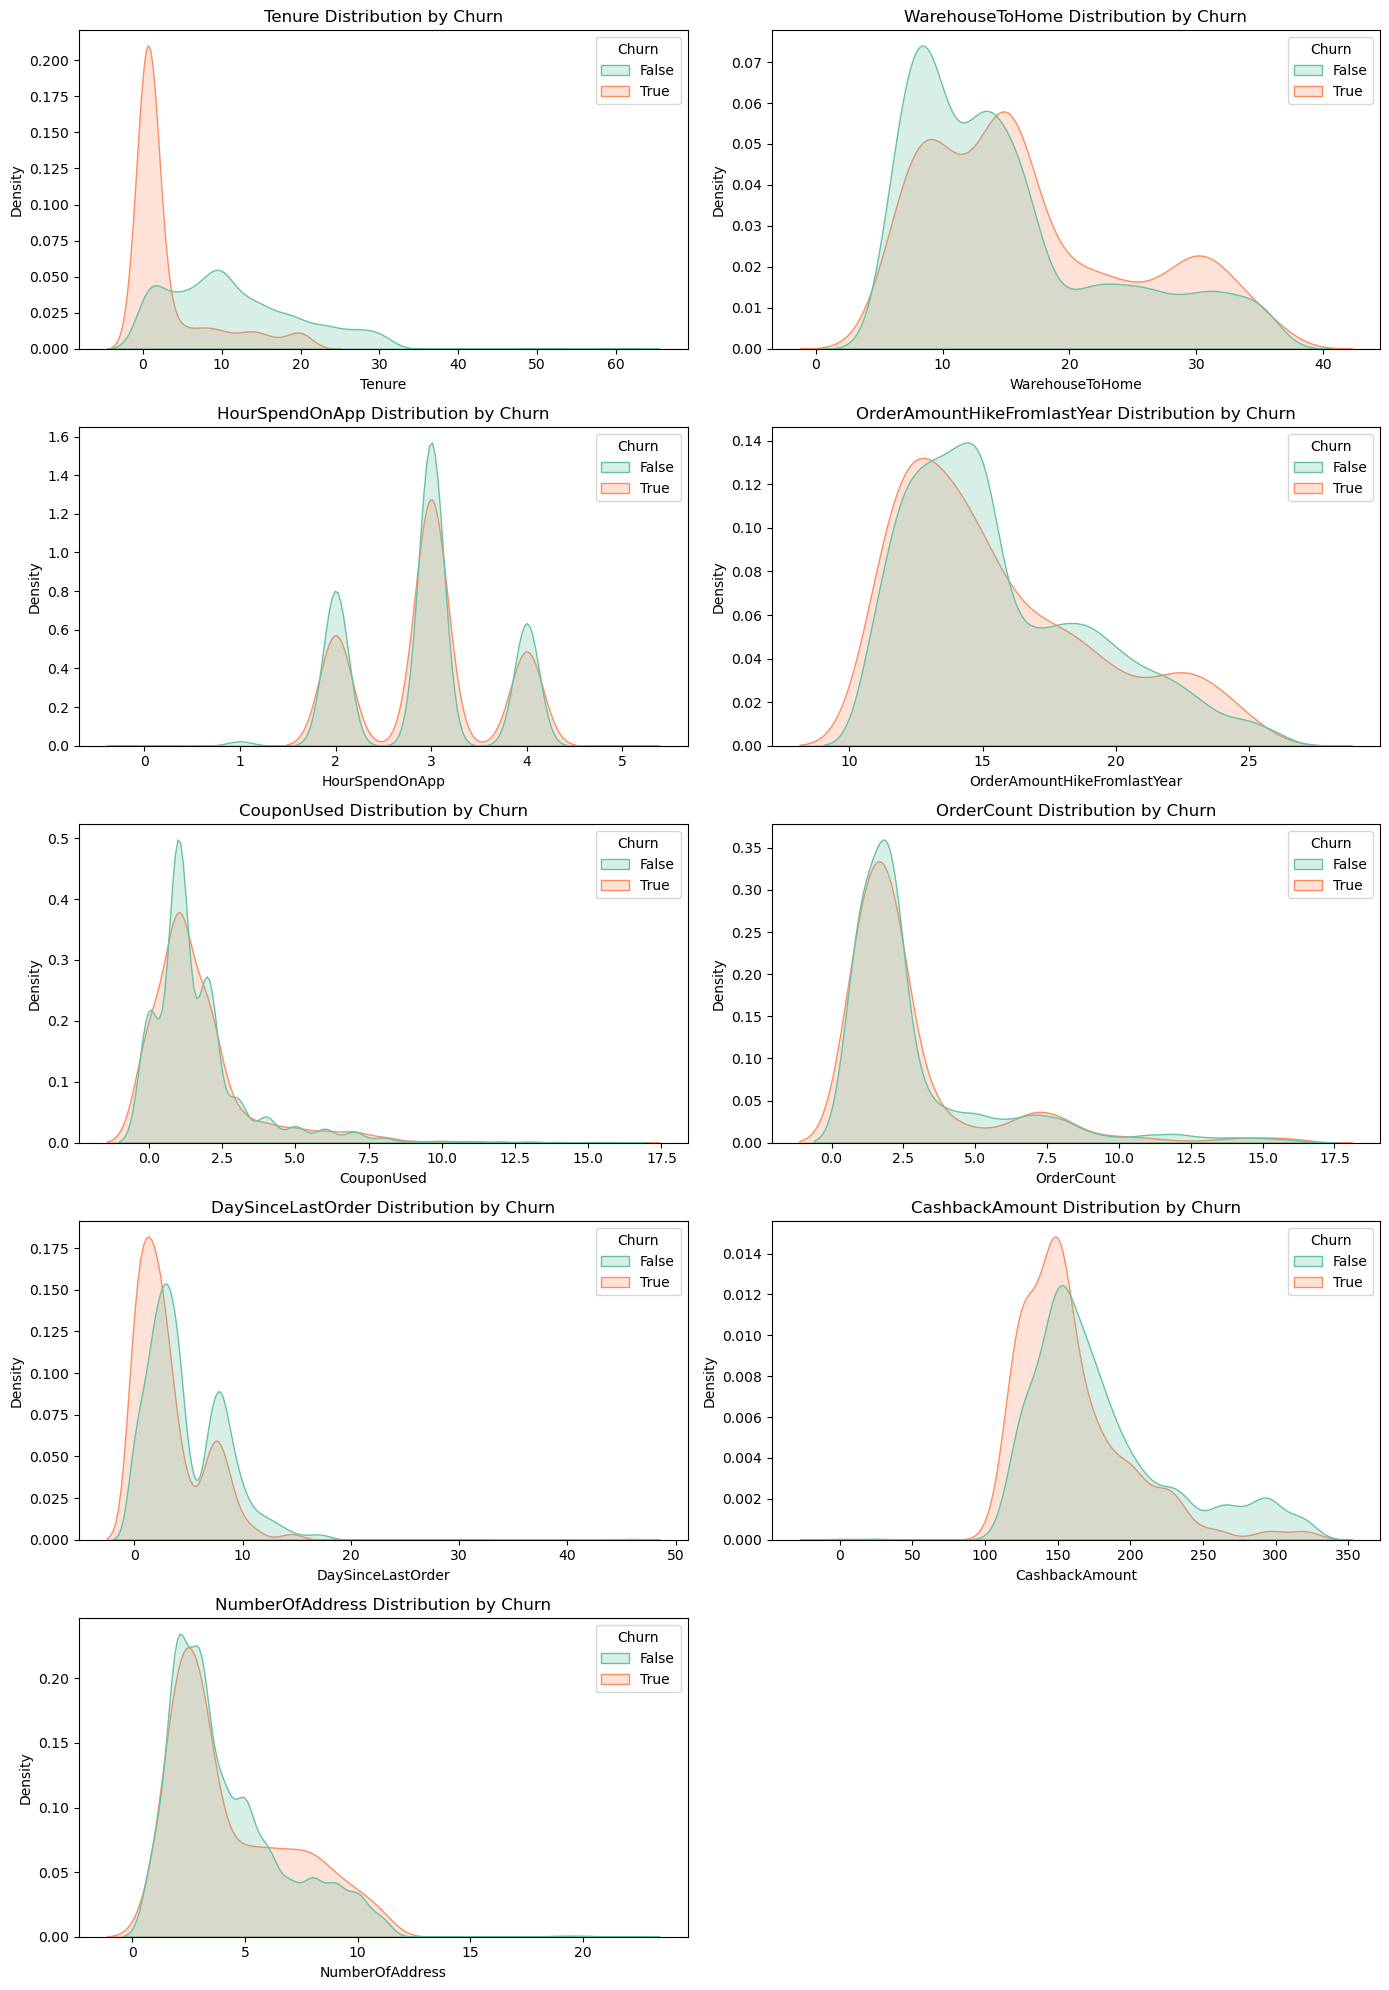

In [14]:
fig, axes = plt.subplots(5, 2, figsize=(14, 20))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    sns.kdeplot(data=df, x=col, hue='Churn', fill=True, common_norm=False, palette='Set2', ax=axes[i])
    axes[i].set_title(f'{col} Distribution by Churn')

axes[-1].axis('off')

plt.tight_layout()
# plt.savefig('../eda/numeric_vs_churn_kdeplots.png', dpi=300, bbox_inches='tight')
plt.show()

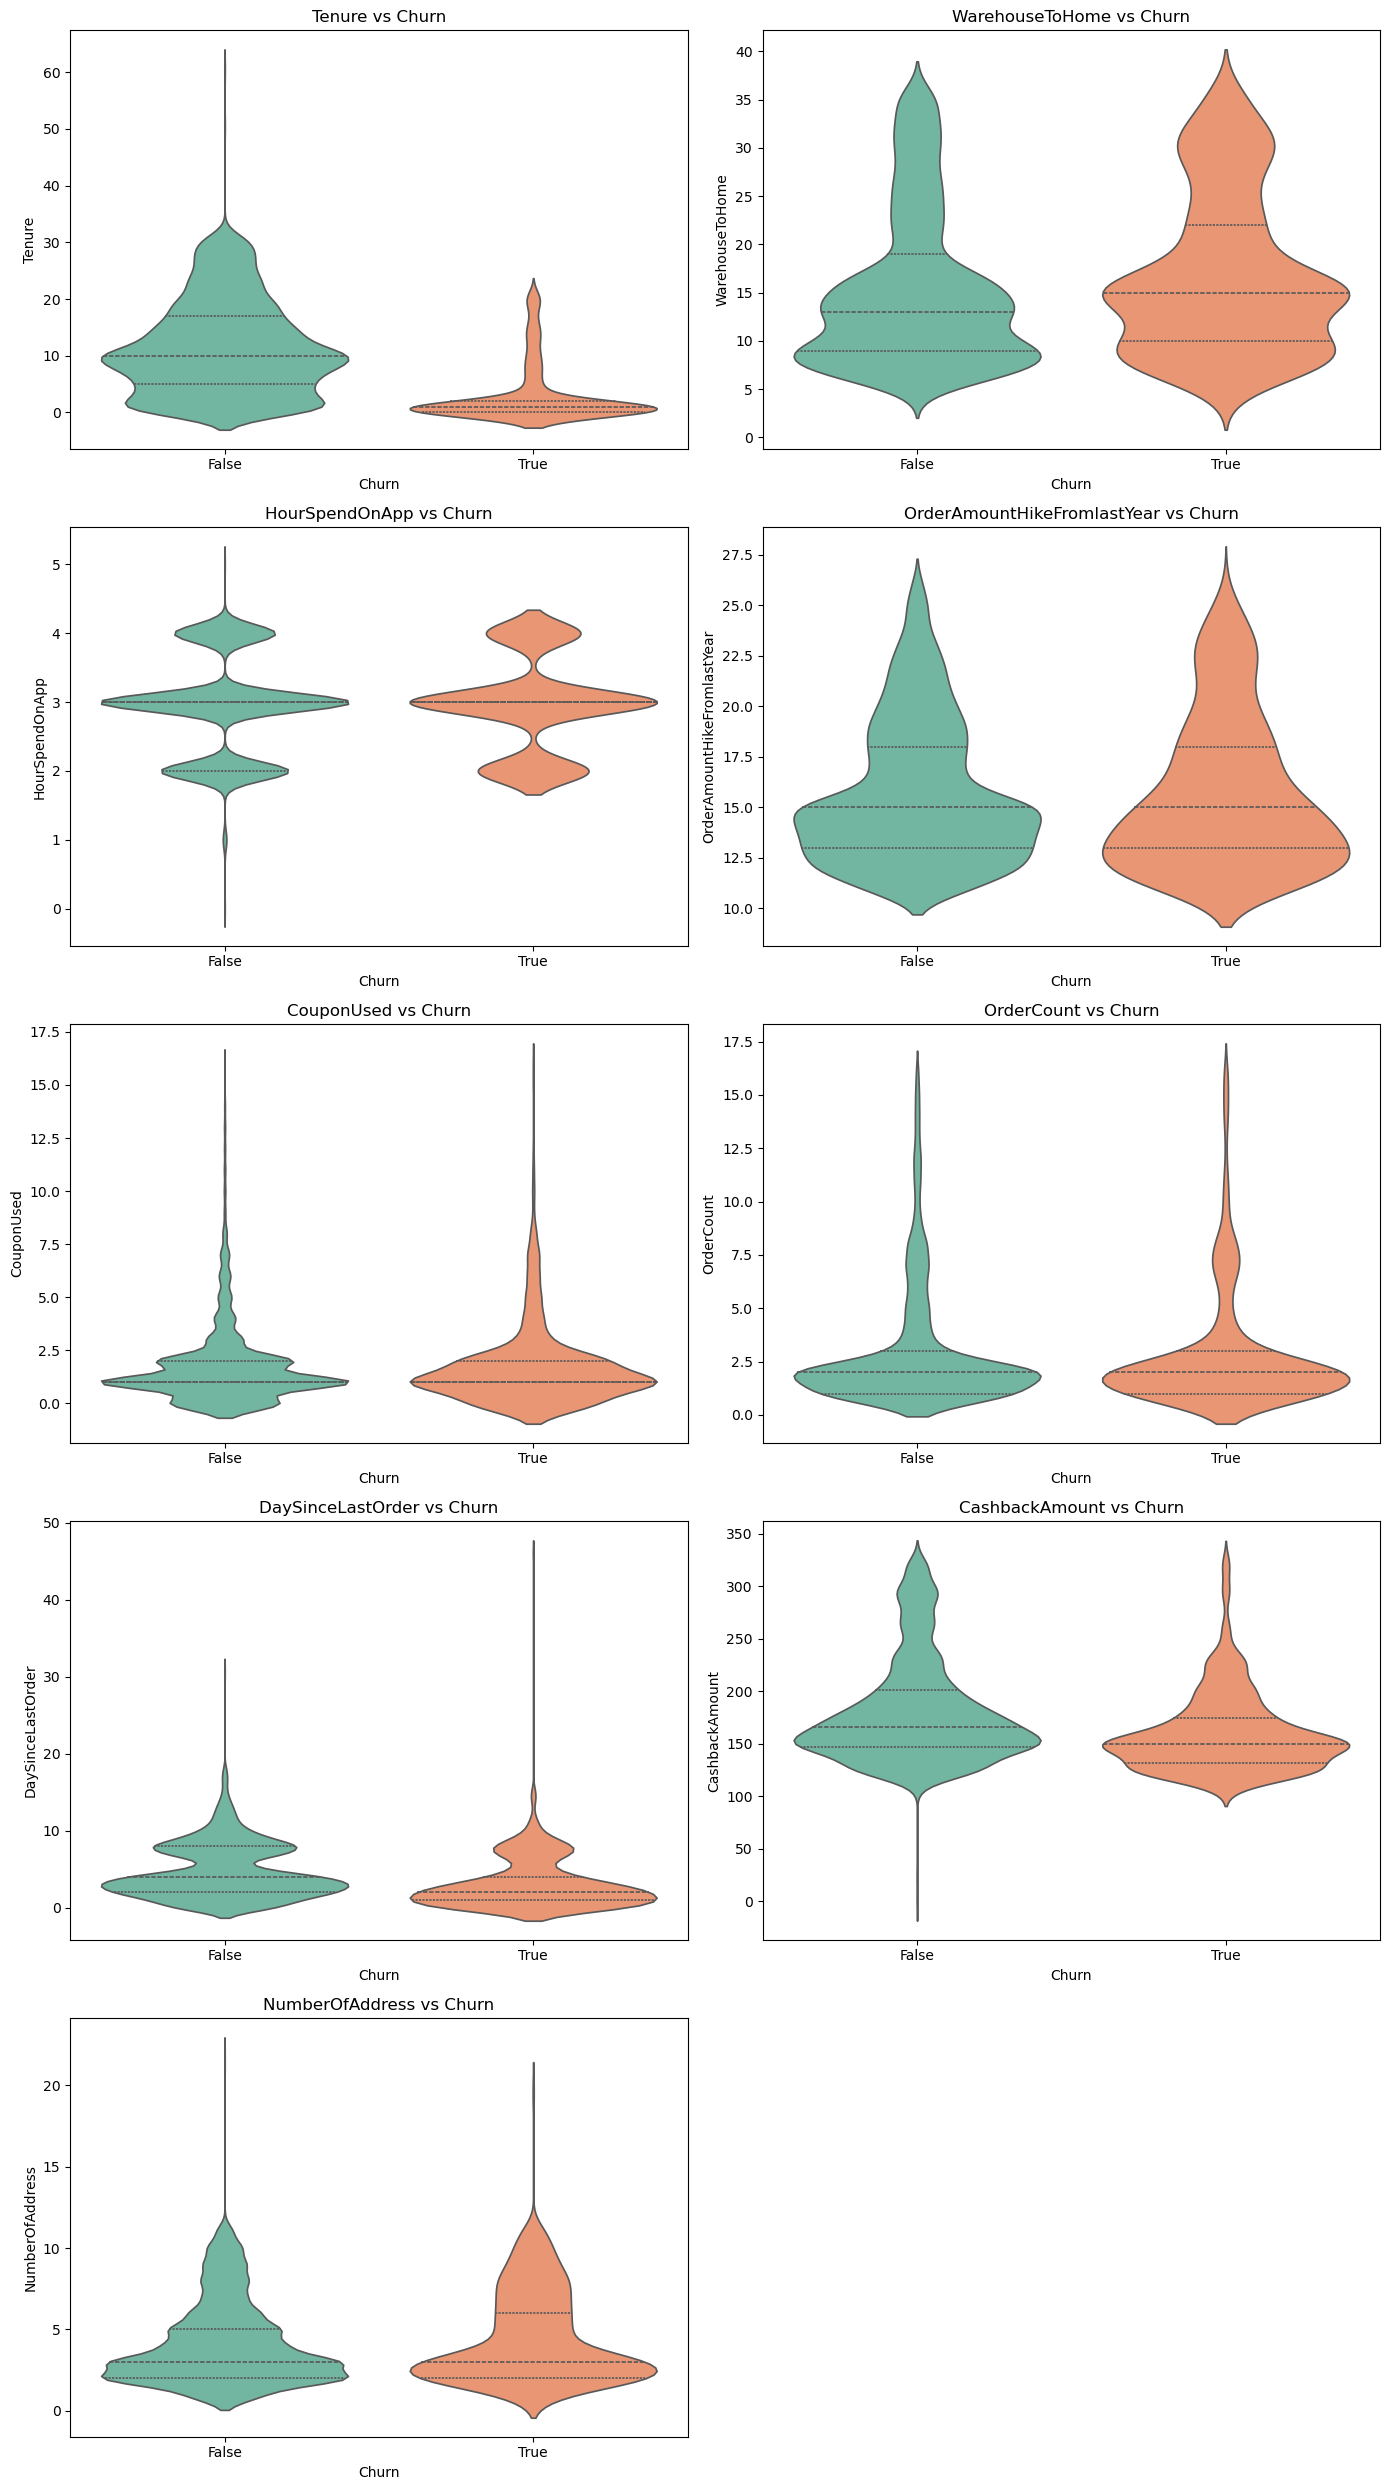

In [15]:
fig, axes = plt.subplots(5, 2, figsize=(14, 25))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    sns.violinplot(data=df, x='Churn', y=col, hue='Churn', palette='Set2', legend=False, inner= "quartile", ax=axes[i])
    axes[i].set_title(f'{col} vs Churn')
    axes[i].set_xlabel('Churn')
    axes[i].set_ylabel(col)

axes[-1].axis('off')

plt.tight_layout()
# plt.savefig('../eda/numeric_vs_churn_violinplots.png', dpi=300, bbox_inches='tight')
plt.show()

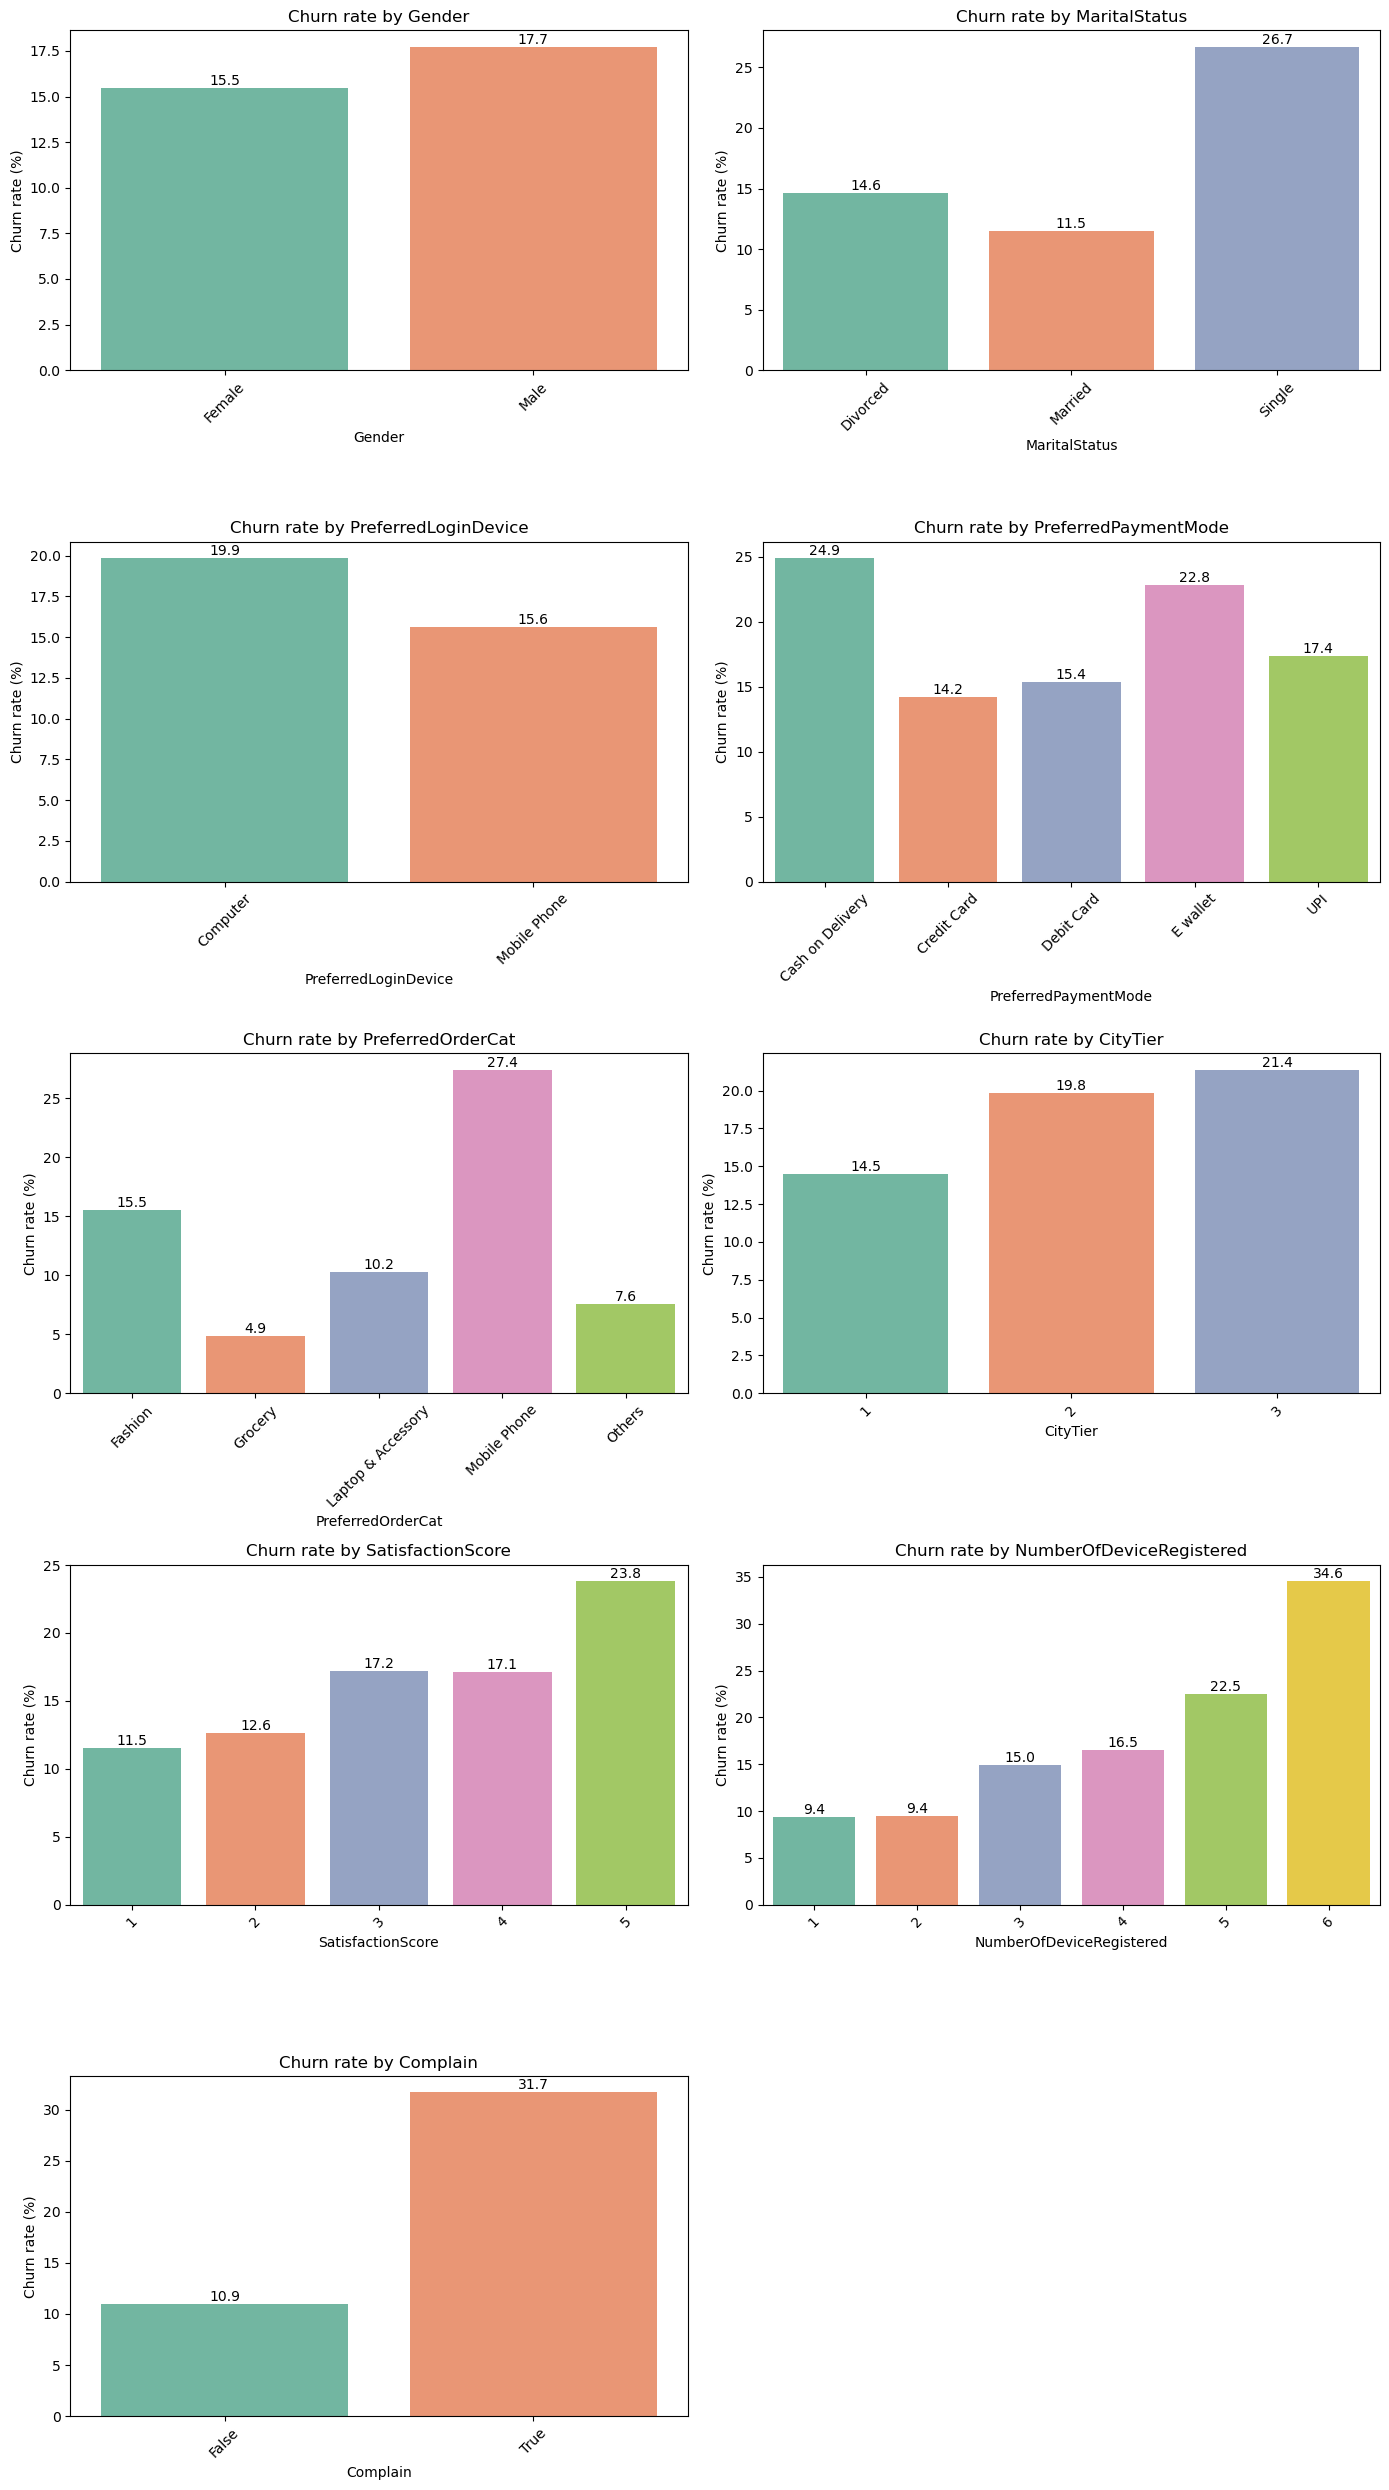

In [16]:
fig,axes = plt.subplots(5,2,figsize = (14,25))
axes = axes.flatten()

for i, col in enumerate(categorical_columns):
    churn_rate = df.groupby(col, observed= True)["Churn"].mean().sort_values(ascending = False) * 100

    sns.barplot(x= churn_rate.index, y = churn_rate.values, hue = churn_rate.index, palette = "Set2", legend = False, ax = axes[i])
    axes[i].set_title(f"Churn rate by {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Churn rate (%)")
    axes[i].tick_params(axis = "x", rotation = 45)

    for container in axes[i].containers:
        axes[i].bar_label(container, fmt = "%.1f")

axes[-1].axis("off")
plt.tight_layout()
# plt.savefig("../eda/churn_rate_by_categorical_columns.png",dpi = 300, bbox_inches = "tight", facecolor = "white")
plt.show()

In [17]:
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferredOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,True,4,Mobile Phone,3,6,Debit Card,Female,3,3,Laptop & Accessory,2,Single,9,True,11,1,1,5,159.93
1,50002,True,1,Mobile Phone,1,8,UPI,Male,3,4,Mobile Phone,3,Single,7,True,15,0,1,0,120.90
2,50003,True,1,Mobile Phone,1,30,Debit Card,Male,2,4,Mobile Phone,3,Single,6,True,14,0,1,3,120.28
3,50004,True,0,Mobile Phone,3,15,Debit Card,Male,2,4,Laptop & Accessory,5,Single,8,False,23,0,1,3,134.07
4,50005,True,0,Mobile Phone,1,12,Credit Card,Male,3,3,Mobile Phone,5,Single,3,False,11,1,1,3,129.60


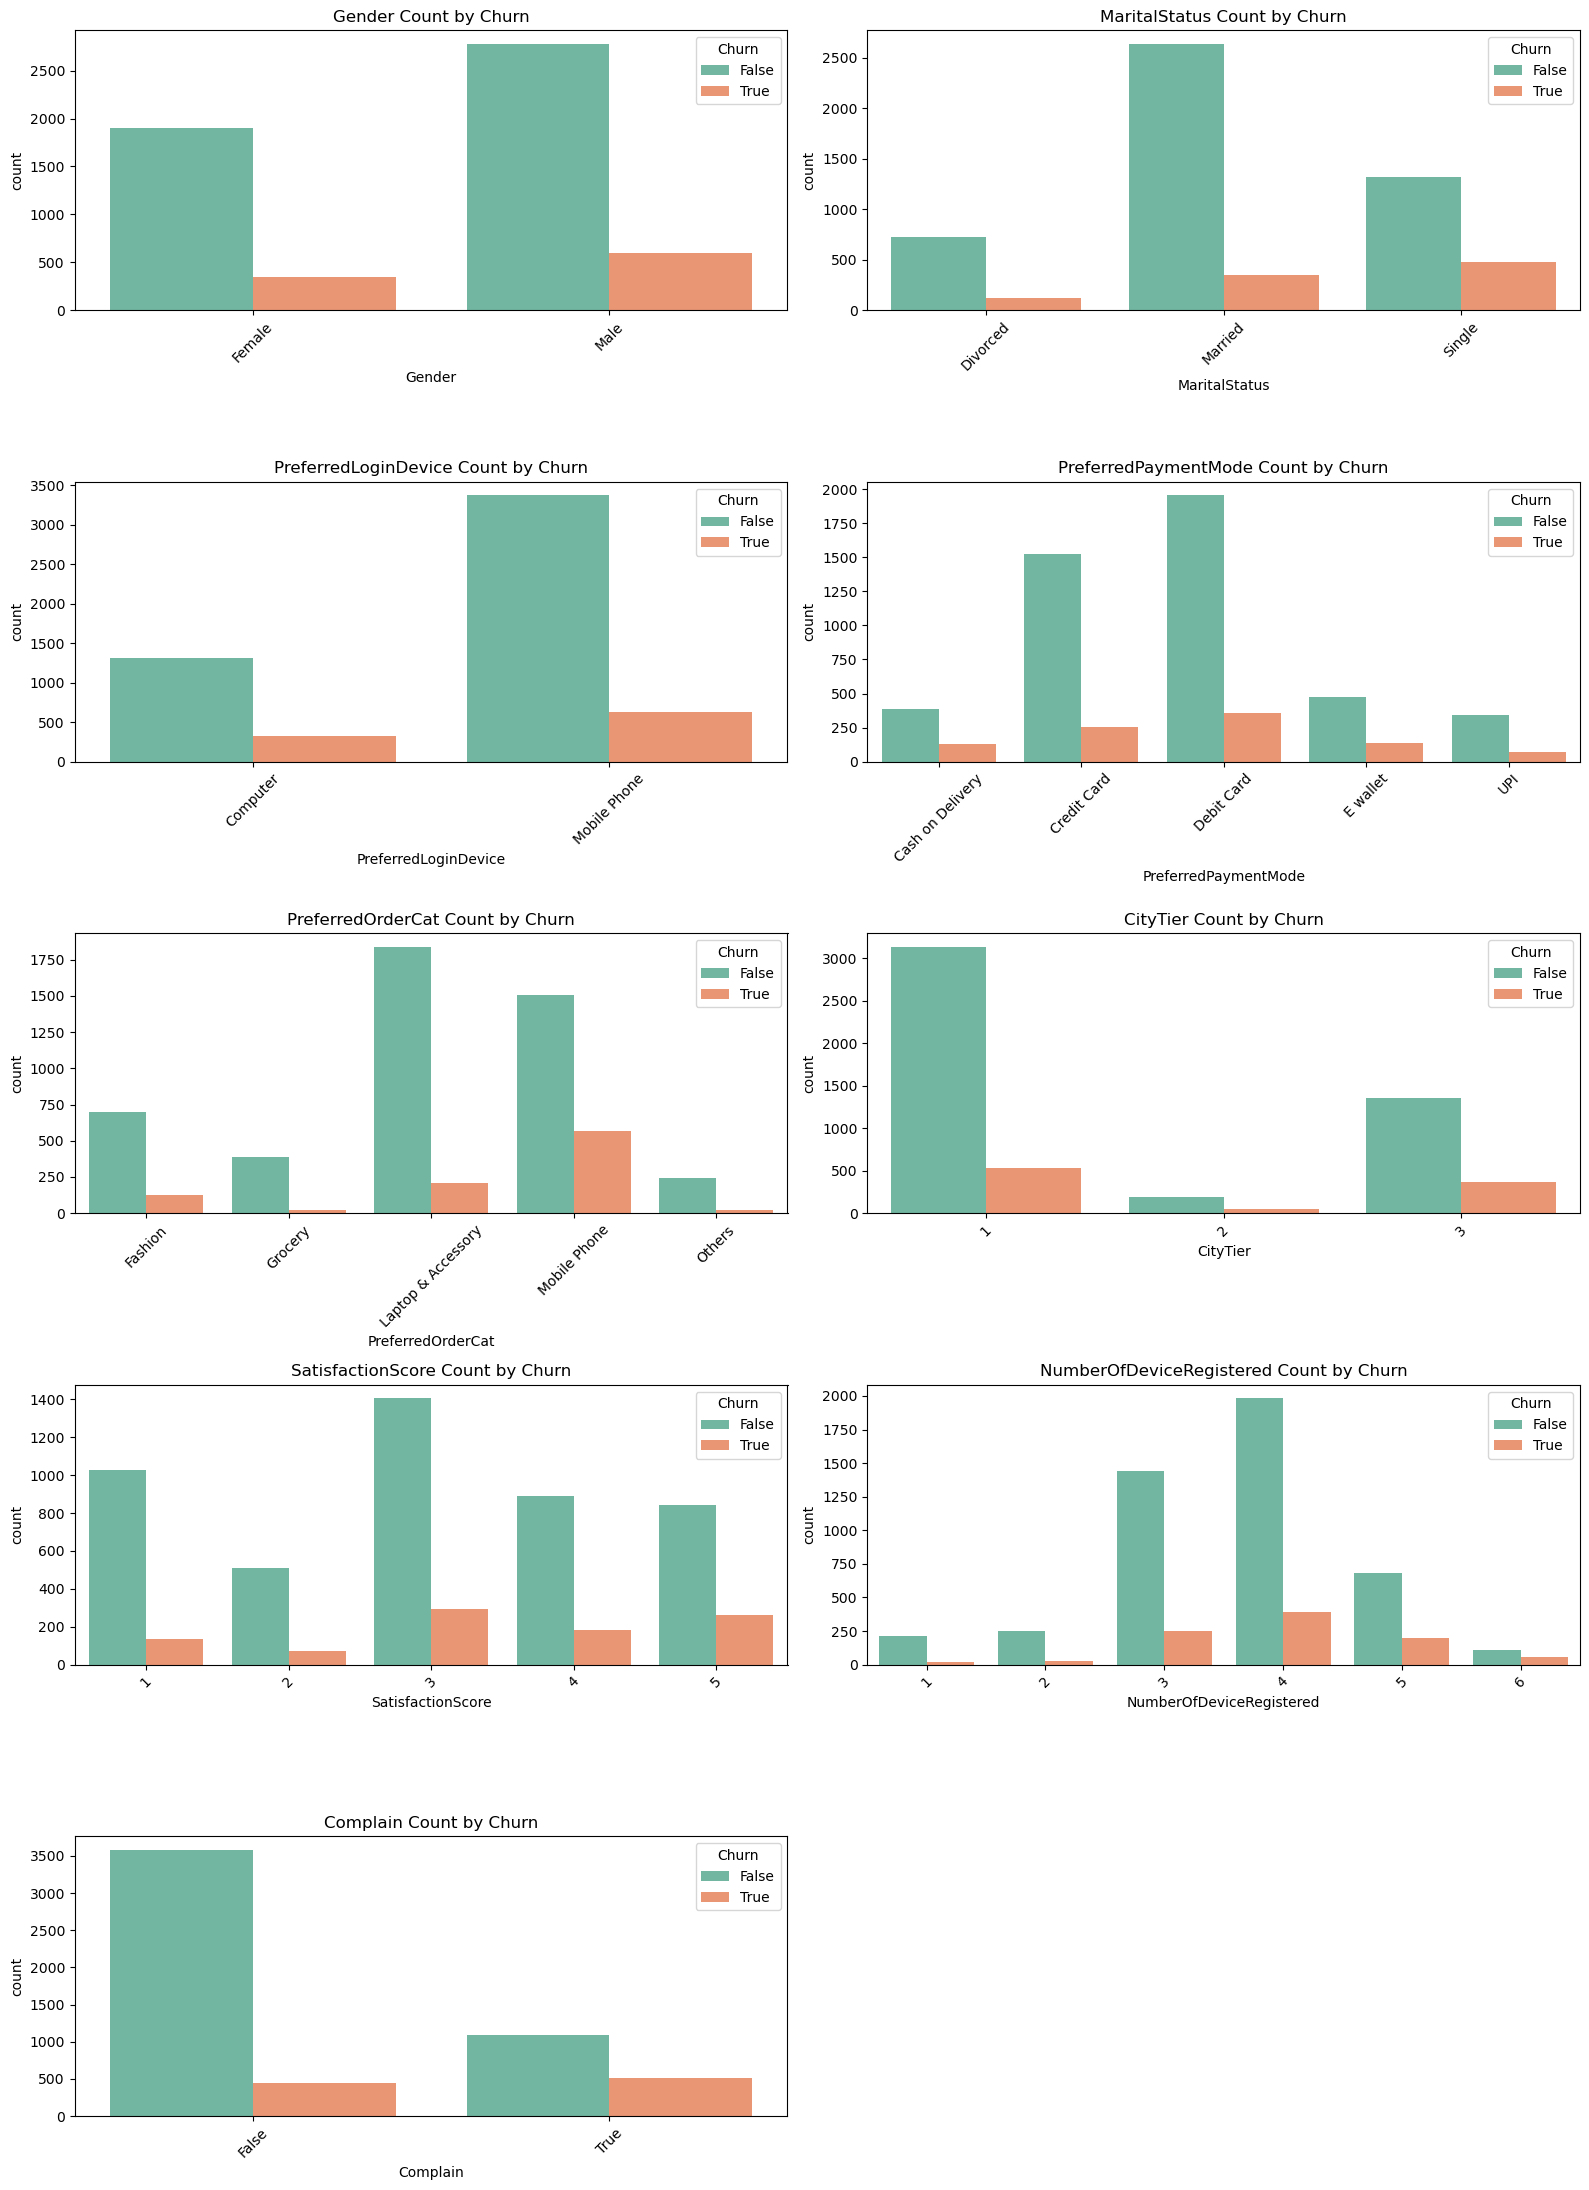

In [18]:
fig,axes = plt.subplots(5,2, figsize = (16,22))
axes = axes.flatten()

for i, col in enumerate(categorical_columns):
    sns.countplot(data = df, x = col, hue = "Churn", palette = "Set2", ax = axes[i])
    axes[i].set_title(f"{col} Count by Churn")
    axes[i].tick_params(axis = "x", rotation = 45)
    axes[i].legend(title = "Churn")

axes[-1].axis("off")
plt.tight_layout()
# plt.savefig("../eda/categorical_countplots_by_churn.png", dpi = 300, bbox_inches = "tight", facecolor = "white")
plt.show()

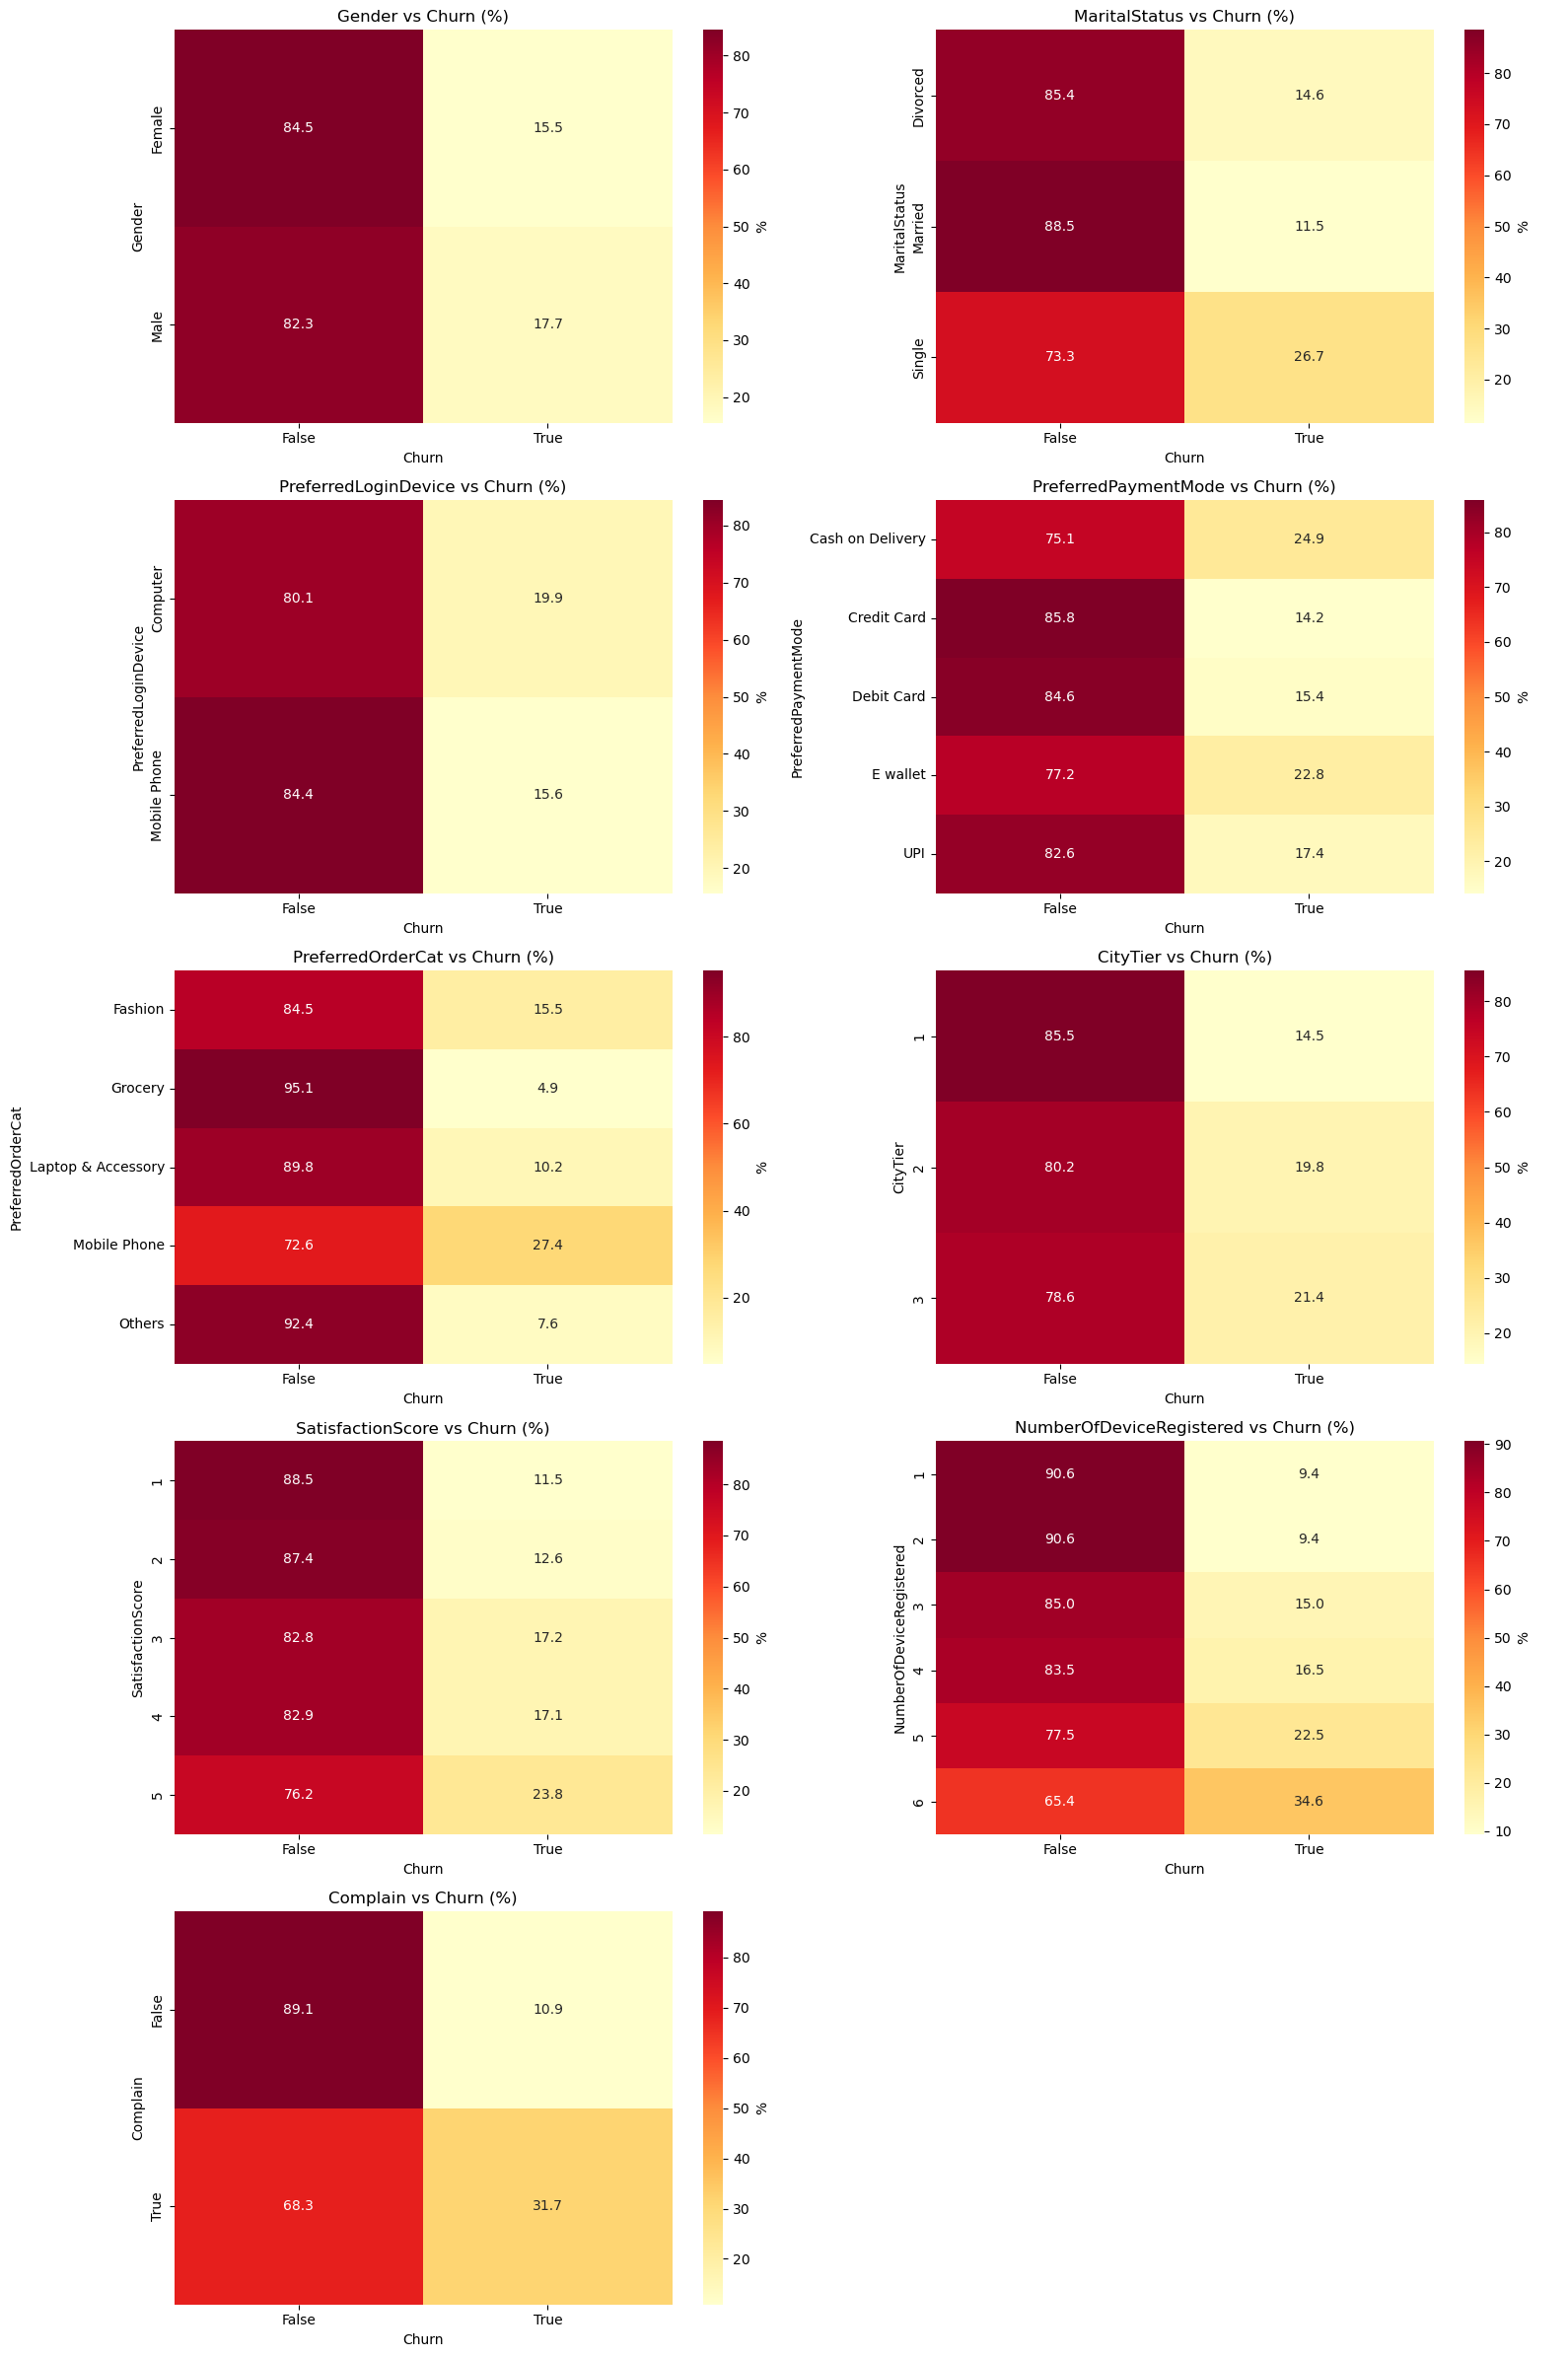

In [19]:
fig, axes = plt.subplots(5,2,figsize = (16,24))
axes = axes.flatten()

for i, col in enumerate(categorical_columns):
    crosstab = pd.crosstab(df[col], df["Churn"], normalize = "index") * 100

    sns.heatmap(crosstab, annot = True,fmt='.1f', cmap='YlOrRd', ax=axes[i], cbar_kws={'label': '%'})
    axes[i].set_title(f'{col} vs Churn (%)')
    axes[i].set_ylabel(col)
    axes[i].set_xlabel('Churn')

axes[-1].axis("off")
plt.tight_layout()
# plt.savefig('../eda/categorical_crosstab_heatmaps.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

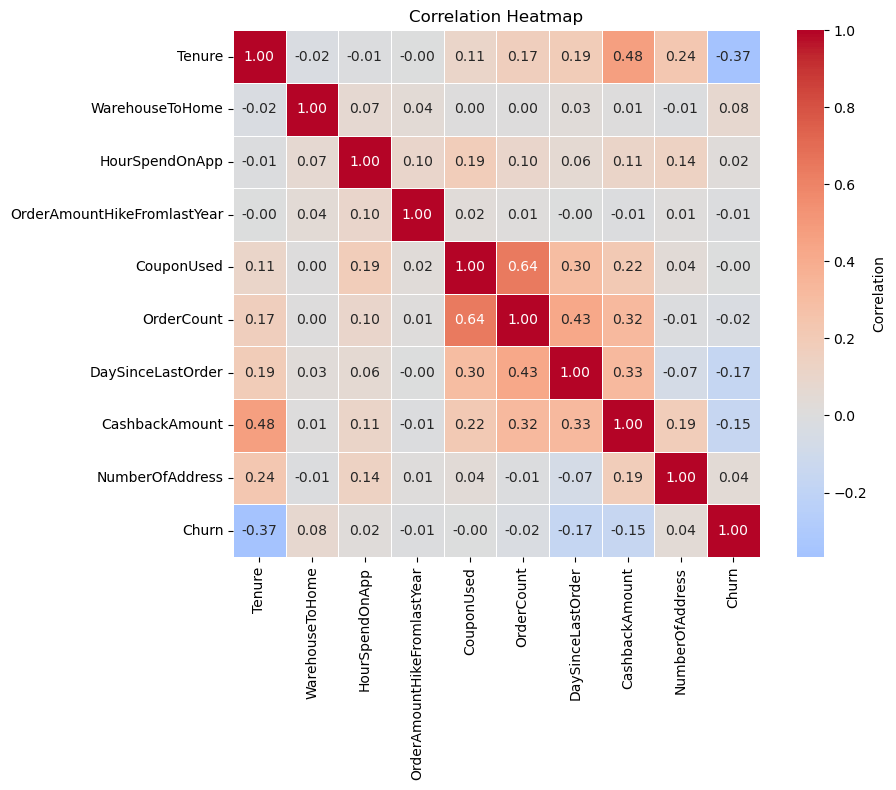

In [20]:
numeric_cols = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'OrderAmountHikeFromlastYear',
                 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount',
                 'NumberOfAddress', 'Churn']

corr_df = df[numeric_cols].copy()
corr_df["Churn"] = corr_df["Churn"].astype(int)

corr_matrix = corr_df.corr()

plt.figure(figsize = (10,8))

sns.heatmap(corr_matrix, annot = True, fmt = ".2f", cmap = "coolwarm", center = 0, square = True, linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title("Correlation Heatmap")
plt.tight_layout()
# plt.savefig("../eda/correlation_heatmap.png", dpi = 300, bbox_inches = "tight", facecolor = "white")
plt.show()

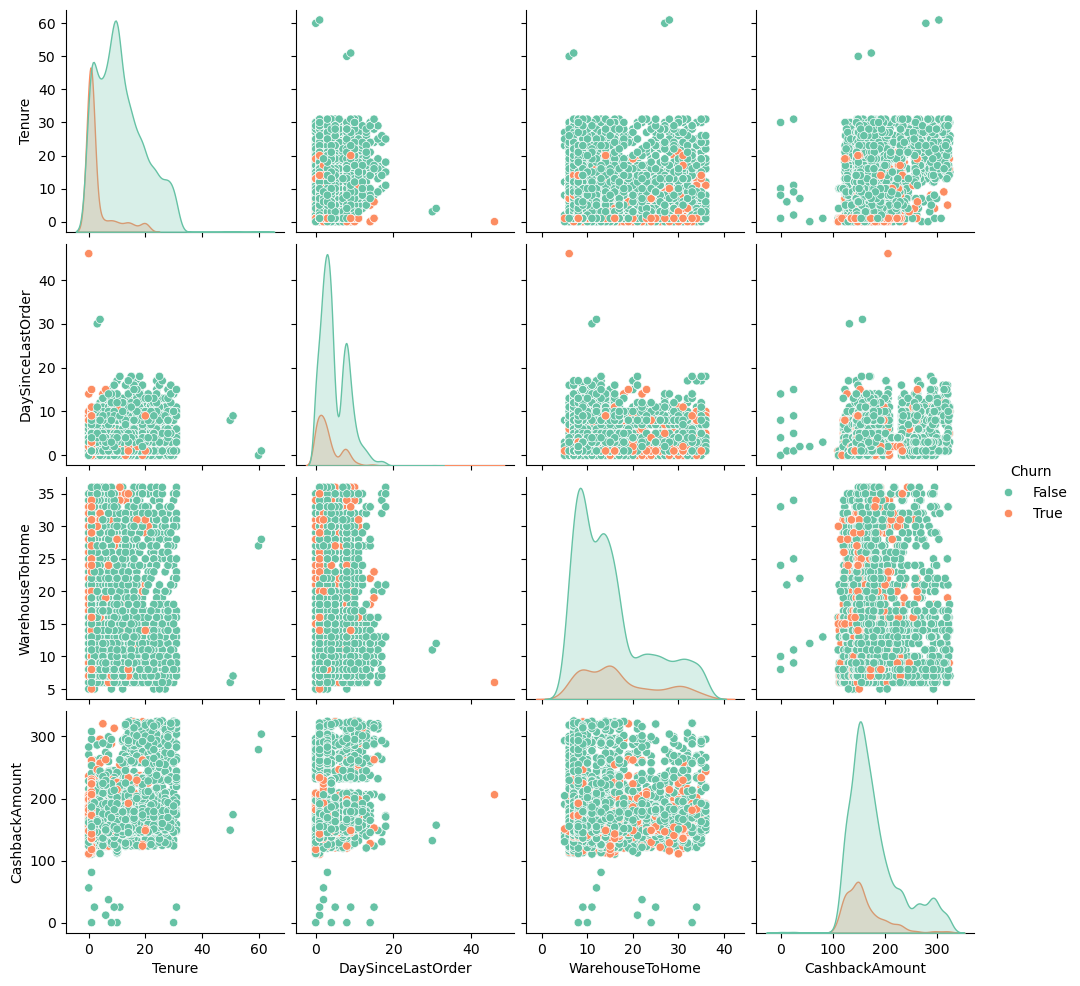

In [ ]:
key_cols = ['Tenure', 'DaySinceLastOrder', 'WarehouseToHome', 'CashbackAmount', 'Churn']

sns.pairplot(df[key_cols], hue = "Churn",palette='Set2', diag_kind='kde', height=2.5)
# plt.savefig("../eda/key_cols_pairplot.png", dpi = 300, bbox_inches = "tight", facecolor = "white")
plt.show()

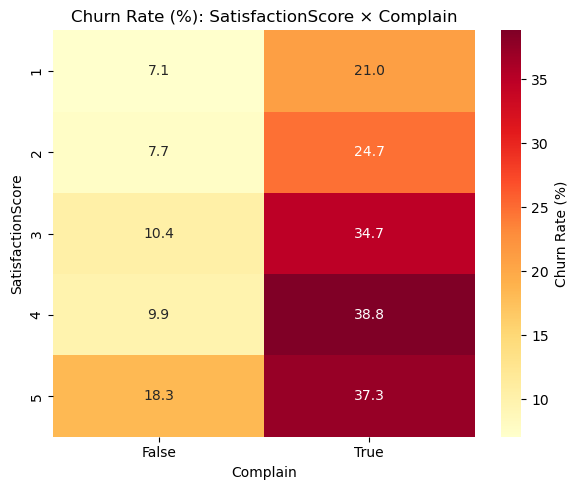

In [ ]:
pivot = df.pivot_table(values='Churn', index='SatisfactionScore', columns='Complain',
                        aggfunc='mean', observed=True) * 100

plt.figure(figsize = (6,5))
sns.heatmap(pivot, annot = True, fmt = ".1f", cmap = "YlOrRd", cbar_kws={'label': 'Churn Rate (%)'})
plt.title('Churn Rate (%): SatisfactionScore × Complain')
plt.tight_layout()
# plt.savefig("../eda/satisfaction_complain_churn_heatmap.png", dpi = 300, bbox_inches = "tight", facecolor = "white")
plt.show()

# EDA Findings Summary — E-Commerce Churn Dataset

## Overview
- **Dataset**: 5,628 customers, 20 features, after cleaning (2 outlier rows removed, all missing values imputed, categorical labels standardized)
- **Churn rate**: 16.8% (940 churned / 4,688 retained) — a moderately imbalanced target

## Strongest Predictors of Churn

**Tenure** is the single strongest signal in the dataset (correlation: -0.37). Churned customers are heavily concentrated at 0–1 months tenure; retained customers spread much more broadly (median ~9-10 months). New customers are far more likely to leave than established ones.

**Complain** is the strongest categorical predictor. Customers who filed a complaint churn at 31.7% vs. 10.9% for those who didn't — nearly a 3x difference.

**NumberOfDeviceRegistered** shows a clear upward trend: churn rises steadily from 9.4% (1–2 devices) to 34.6% (6 devices). More registered devices associates with higher churn risk.

**PreferredOrderCat** — Mobile Phone category churns at 27.4%, far above Grocery (4.9%) or Others (7.6%).

**MaritalStatus** — Single customers churn at 26.7%, more than double the rate of Married customers (11.5%).

**DaySinceLastOrder** (correlation: -0.17) and **CashbackAmount** (correlation: -0.15) show moderate negative relationships — customers with more recent orders and higher cashback earnings are less likely to churn.

**CityTier** — Tier 1 customers churn least (14.5%) vs. Tier 3 (21.4%); Tier 2's 19.8% rests on a small sample (~250 customers) and should be treated cautiously.

## Weak or No Predictors
`HourSpendOnApp`, `OrderAmountHikeFromlastYear`, `CouponUsed`, `OrderCount`, `Gender`, `PreferredLoginDevice`, and `WarehouseToHome` all show minimal separation between churned and retained customers, both visually (overlapping boxplots/KDEs) and statistically (correlations near 0).

## Most Notable, Non-Obvious Finding
**Satisfaction score does not protect against churn when a complaint is involved.** Among customers who complained, churn rate climbs *with* satisfaction score — even customers who rated satisfaction 4 or 5 still churned at 37–39% if they'd filed a complaint. This suggests the complaint itself (or how well it was resolved) is a stronger driver of churn than the customer's self-reported satisfaction. This is a genuinely actionable insight for a retention strategy — resolving complaints effectively may matter more than the satisfaction score alone.

## Data Quality Notes Worth Carrying Forward
- `NumberOfDeviceRegistered` and `CouponUsed`/`OrderCount` are correlated with each other (0.64) — worth checking for multicollinearity if using a linear model.
- `CityTier = 2` has a small sample size; interpret its churn rate with caution.
- `Tenure`, `DaySinceLastOrder`, `WarehouseToHome` had missing values imputed via group-wise median (by Churn); this preserved the distributional differences between groups rather than flattening them.

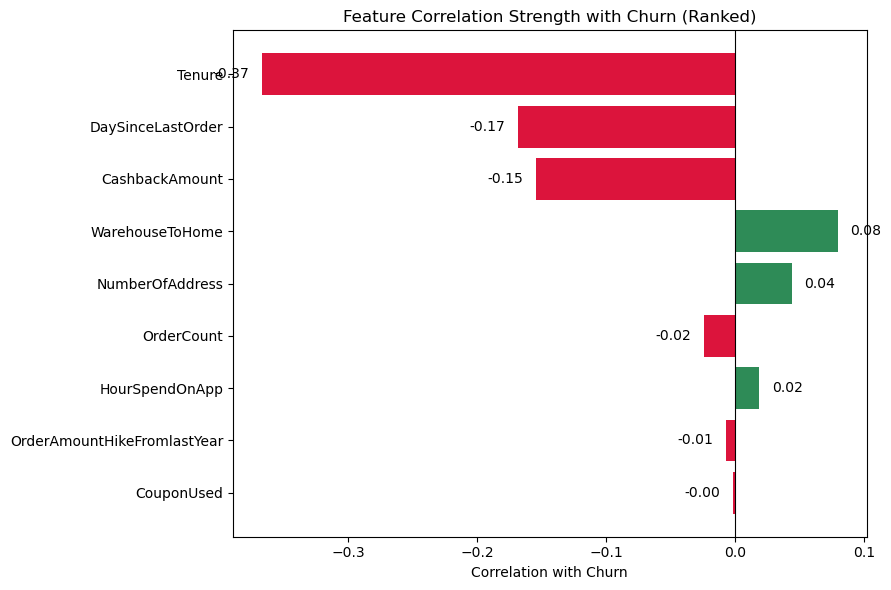

In [24]:
corr_with_churn = corr_matrix['Churn'].drop('Churn').sort_values(key=abs, ascending=False)

plt.figure(figsize=(9, 6))
colors = ['crimson' if v < 0 else 'seagreen' for v in corr_with_churn.values]
bars = plt.barh(corr_with_churn.index, corr_with_churn.values, color=colors)

plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Correlation with Churn')
plt.title('Feature Correlation Strength with Churn (Ranked)')
plt.gca().invert_yaxis()  # strongest at top

for bar, val in zip(bars, corr_with_churn.values):
    plt.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
              f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right')

plt.tight_layout()
# plt.savefig('churn_correlation_ranking.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

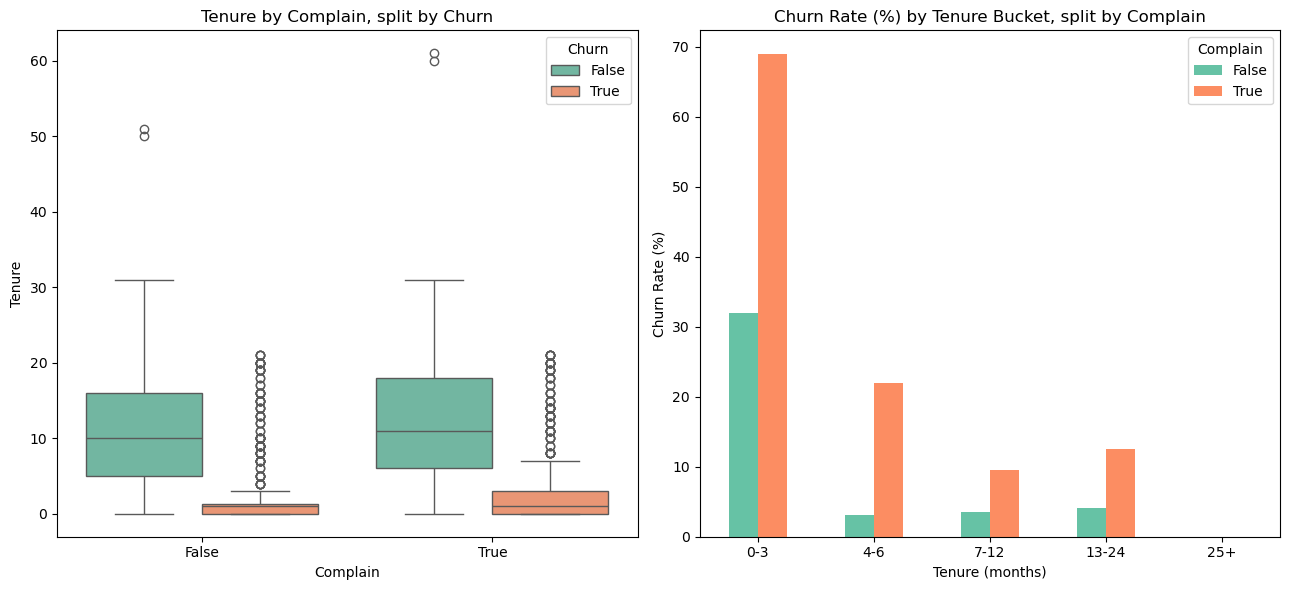

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# Boxplot
sns.boxplot(data=df, x='Complain', y='Tenure', hue='Churn', palette='Set2', ax=axes[0])
axes[0].set_title('Tenure by Complain, split by Churn')
axes[0].set_xlabel('Complain')
axes[0].set_ylabel('Tenure')

# Grouped churn rate bar chart (mean churn rate by Tenure bucket x Complain)
df['TenureBucket'] = pd.cut(df['Tenure'], bins=[-1, 3, 6, 12, 24, 100],
                              labels=['0-3', '4-6', '7-12', '13-24', '25+'])

pivot = df.pivot_table(values='Churn', index='TenureBucket', columns='Complain',
                        aggfunc='mean', observed=True) * 100

pivot.plot(kind='bar', ax=axes[1], color=['#66c2a5', '#fc8d62'])
axes[1].set_title('Churn Rate (%) by Tenure Bucket, split by Complain')
axes[1].set_xlabel('Tenure (months)')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].legend(title='Complain')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
# plt.savefig('tenure_complain_interaction.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()